# Milo tutorial via **omicverse** (`ov.single.DCT(method='milopy')`)

Differential abundance testing on single-cell data using the Milo
k-NN-neighbourhood framework (Dann et al., *Nature Biotechnology* 2022).
This notebook is the "DCT with milo" section of the omicverse
`t_deg_single` tutorial, adapted as a standalone example.

**Data**: Haber et al. 2017 mouse intestinal epithelium (Control vs
Salmonella, ~5 k cells × 15 k genes).

**Backend**: this walks through the `ov.single.DCT` wrapper, which
dispatches to the canonical `omicverse.single.Milo` class — the same
code this repo mirrors as `from milor_py import Milo`.


In [1]:
import warnings; warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
import omicverse as ov

ov.plot_set()
adata = ov.read('/scratch/users/steorra/analysis/26_omic_protocol/data/haber_2017_regions.h5ad')
print(adata)

🔬 Starting plot initialization...
🧬 Detecting GPU devices…
✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3
      Memory: 79.1 GB | Compute: 9.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.1.1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



AnnData object with n_obs × n_vars = 9842 × 15215
    obs: 'batch', 'barcode', 'condition', 'cell_label'


## 1. Subset to Control vs Salmonella

In [2]:
adata = adata[adata.obs['condition'].isin(['Control', 'Salmonella'])].copy()
print(adata.obs['condition'].value_counts())

condition
Control       3240
Salmonella    1770
Name: count, dtype: int64


## 2. Preprocess, batch-correct, build the k-NN graph

Milo's index sampling + neighbourhood expansion both operate on the
k-NN graph, so a clean batch-corrected PC space matters.

In [3]:
adata = ov.pp.preprocess(adata, mode='shiftlog|pearson',
                          n_HVGs=2000, target_sum=50*1e4)
adata.raw = adata
adata = adata[:, adata.var.highly_variable_features]
ov.single.batch_correction(adata, batch_key='batch',
                            methods='harmony', n_pcs=50)
ov.pp.neighbors(adata, n_neighbors=15, n_pcs=50,
                use_rep='X_pca_harmony')
ov.pp.umap(adata)

🔍 [2026-04-17 18:40:33] Running preprocessing in 'cpu' mode...
Begin robust gene identification
    After filtration, 15215/15215 genes are kept.
    Among 15215 genes, 15215 genes are robust.
✅ Robust gene identification completed successfully.
Begin size normalization: shiftlog and HVGs selection pearson



🔍 Count Normalization:
   Target sum: 500000.0
   Exclude highly expressed: True
   Max fraction threshold: 0.2
   ⚠️ Excluding 12 highly-expressed genes from normalization computation



✅ Count Normalization Completed Successfully!
   ✓ Processed: 5,010 cells × 15,215 genes
   ✓ Runtime: 0.61s

🔍 Highly Variable Genes Selection (Experimental):
   Method: pearson_residuals
   Target genes: 2,000
   Theta (overdispersion): 100



✅ Experimental HVG Selection Completed Successfully!
   ✓ Selected: 2,000 highly variable genes out of 15,215 total (13.1%)
   ✓ Results added to AnnData object:
     • 'highly_variable': Boolean vector (adata.var)
     • 'highly_variable_rank': Float vector (adata.var)
     • 'highly_variable_nbatches': Int vector (adata.var)
     • 'highly_variable_intersection': Boolean vector (adata.var)
     • 'means': Float vector (adata.var)
     • 'variances': Float vector (adata.var)
     • 'residual_variances': Float vector (adata.var)
    Time to analyze data in cpu: 6.67 seconds.
✅ Preprocessing completed successfully.
    Added:
        'highly_variable_features', boolean vector (adata.var)
        'means', float vector (adata.var)
        'variances', float vector (adata.var)
        'residual_variances', float vector (adata.var)
        'counts', raw counts layer (adata.layers)
    End of size normalization: shiftlog and HVGs selection pearson

╭─ SUMMARY: preprocess ───────────────────

...Begin using harmony to correct batch effect


...

Harmony converged after 6 iterations:  50%|██████████████████████████                          | 5/10 [00:01<00:01,  3.62it/s]

✅ Harmony converged after 6 iterations



╭─ SUMMARY: batch_correction ────────────────────────────────────────╮
│  Duration: 66.017s                                                 │
│  Shape:    5,010 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● OBSM   │ ✚ X_harmony (array, 5010x50)                           │
│           │ ✚ X_pca_harmony (array, 5010x50)                       │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯
🖥️ Using Scanpy CPU to calculate neighbors...

🔍 K-Nearest Neighbors Graph Construction:
   Mode: cpu
   Neighbors: 15
   Method: umap
   Metric: euclidean
   Representation: X_pca_harmony
   PCs used: 50
   🔍 Computing neighbor distances...
   🔍 Computing connectivity matrix...
   💡 Usin

   ✓ Graph is fully connected

✅ KNN Graph Construction Completed Successfully!
   ✓ Processed: 5,010 cells with 15 neighbors each
   ✓ Results added to AnnData object:
     • 'neighbors': Neighbors metadata (adata.uns)
     • 'distances': Distance matrix (adata.obsp)
     • 'connectivities': Connectivity matrix (adata.obsp)

╭─ SUMMARY: neighbors ───────────────────────────────────────────────╮
│  Duration: 1.5009s                                                 │
│  Shape:    5,010 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ neighbors                                            │
│           │ └─ params: {'n_neighbors': 15, 'method': 'umap', 'random_s...│
│                                                                    │
│  ● OBSP   │ ✚ connectivit


✅ UMAP Dimensionality Reduction Completed Successfully!
   ✓ Embedding shape: 5,010 cells × 2 dimensions
   ✓ Results added to AnnData object:
     • 'X_umap': UMAP coordinates (adata.obsm)
     • 'umap': UMAP parameters (adata.uns)
✅ UMAP completed successfully.

╭─ SUMMARY: umap ────────────────────────────────────────────────────╮
│  Duration: 1.0114s                                                 │
│  Shape:    5,010 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ umap                                                 │
│           │ └─ params: {'a': np.float64(0.5830300203414425), 'b': np.f...│
│                                                                    │
│  ● OBSM   │ ✚ X_umap (array, 5010x2)                               │
│                 

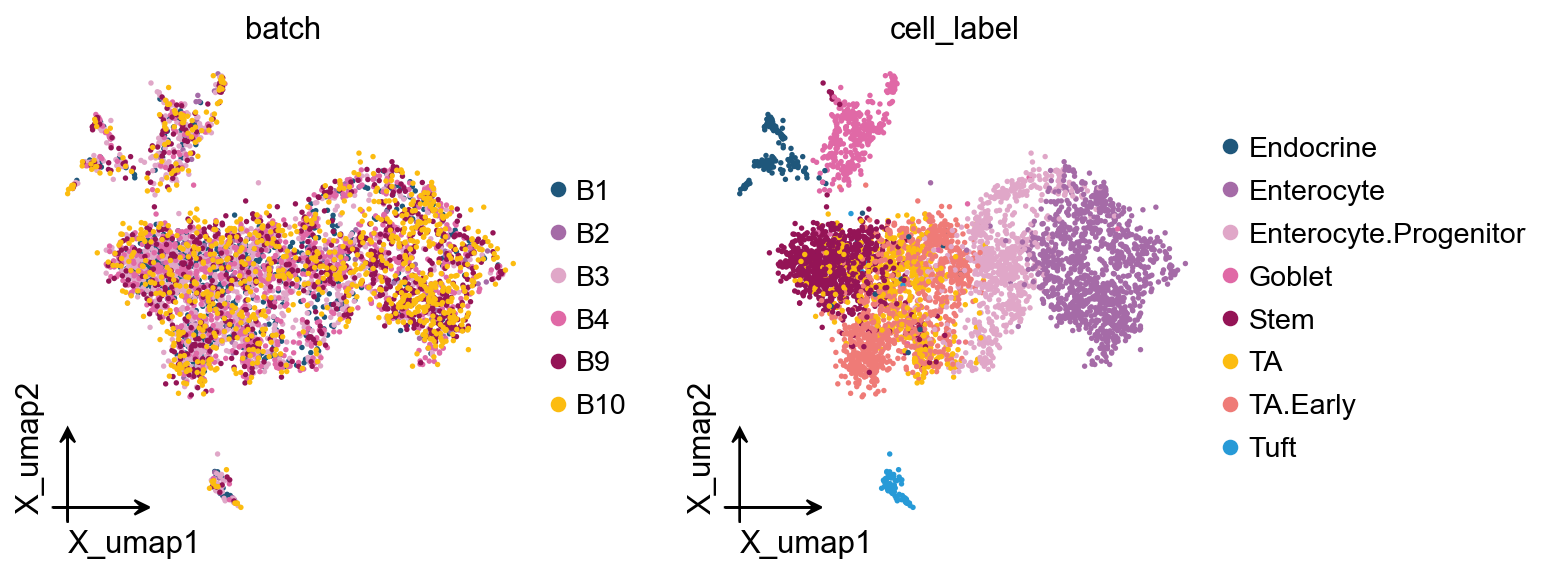

In [4]:
ov.pl.embedding(adata, basis='X_umap',
                color=['batch', 'cell_label'], frameon='small')

## 3. Run differential abundance with `ov.single.DCT`

`method='milopy'` routes through `omicverse.single.Milo` (the same
class this repo exports as `from milor_py import Milo`). Internally
it runs `make_nhoods → count_nhoods → da_nhoods → build_nhood_graph`
in one step.

In [5]:
dct = ov.single.DCT(
    adata, condition='condition',
    ctrl_group='Control', test_group='Salmonella',
    cell_type_key='cell_label', method='milopy',
    sample_key='batch', use_rep='X_pca_harmony',
)
dct.run()

✅ Differential cell type abundance analysis initialized
📊 DCT analysis using milopy method
📊 Condition: condition, Control group: Control, Test group: Salmonella


Calculating TMM normalization factors...
TMM factors: [0.98058051 1.02288373 1.00220732 1.06073116 0.96960253 0.96723908]
Original lib_sizes: [11045  2541 16510 13151 10996 12966]
Effective lib_sizes: [10830.51169989  2599.14754859 16546.44292617 13949.67545224
 10661.74941841 12541.22195976]
Design matrix columns: ['condition[Control]', 'condition[Salmonella]']
Model contrasts: condition[Salmonella]-condition[Control]
  Contrast term 'condition[Salmonella]' (index 1): +1
  Contrast term 'condition[Control]' (index 0): -1
Contrast vector: [-1.  1.]
✓ Contrast sums to 0 (valid difference contrast)
edgepy result columns: ['logFC', 'lfcSE', 'logCPM', 'stat', 'PValue', 'FDR', 'adj_pvalue']
✅ milopy DCT analysis completed


## 4. Inspect DA results

`dct.mdata['milo']` is an AnnData keyed by *neighbourhood* (not cell).
Its `.var` carries `logFC`, `PValue`, `SpatialFDR` plus
`nhood_annotation` (majority-vote cell type) and
`nhood_annotation_frac` (fraction of cells carrying that label).

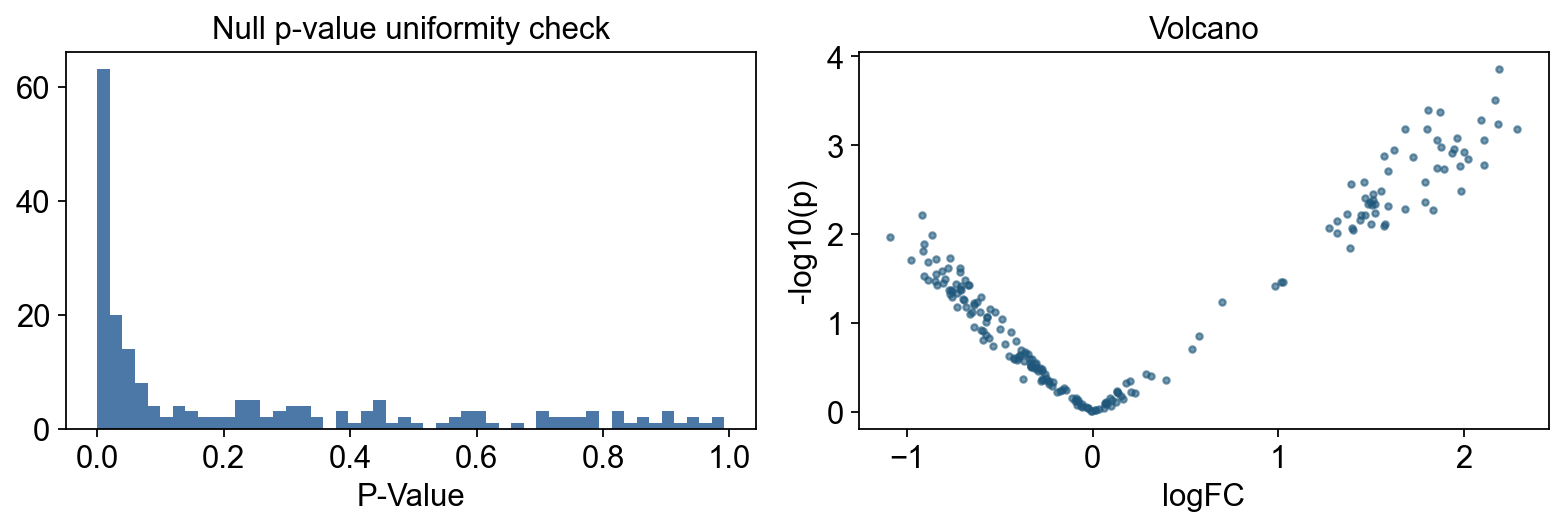

In [6]:
milo_var = dct.mdata['milo'].var
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].hist(milo_var['PValue'], bins=50, color='#4c78a8')
axes[0].set_xlabel('P-Value'); axes[0].set_title('Null p-value uniformity check')
axes[1].scatter(milo_var['logFC'], -np.log10(milo_var['PValue']),
                 s=8, alpha=0.6)
axes[1].set_xlabel('logFC'); axes[1].set_ylabel('-log10(p)')
axes[1].set_title('Volcano')
plt.tight_layout(); plt.show()

Many neighbourhoods span multiple cell types. We call those whose
dominant label covers < 60 % of cells "Mixed".

In [7]:
res = dct.get_results(mix_threshold=0.6)
res.head()

                                        index_cell  kth_distance     logFC  \
0  B1_AATAAGCTAGAGAT_Control_Enterocyte.Progenitor     11.099010 -0.866578   
1                 B1_ACATGGTGCCGTTC_Control_Goblet     15.173621  0.032140   
2                   B1_AGCGGCACCAGAAA_Control_Stem      9.497760 -0.756480   
3                     B1_ATTCAAGATTCACT_Control_TA      9.658766 -0.716897   
4                     B1_CCTAGAGAATTCGG_Control_TA      9.027864 -0.396976   

      lfcSE     logCPM       stat    PValue       FDR  adj_pvalue  SpatialFDR  \
0  0.035030  12.302315  10.141406  0.010147  0.036964    0.036964    0.035969   
1  0.028461  11.850510   0.005731  0.941199  0.960023    0.960023    0.957707   
2  0.028262  13.157448   5.391549  0.043446  0.100717    0.100717    0.100037   
3  0.029983  12.769304   6.845279  0.026425  0.079274    0.079274    0.078422   
4  0.026386  13.108368   1.581743  0.238019  0.376402    0.376402    0.375792   

   Nhood_size nhood_annotation  nhood_annota

## 5. Visualise neighbourhood DA

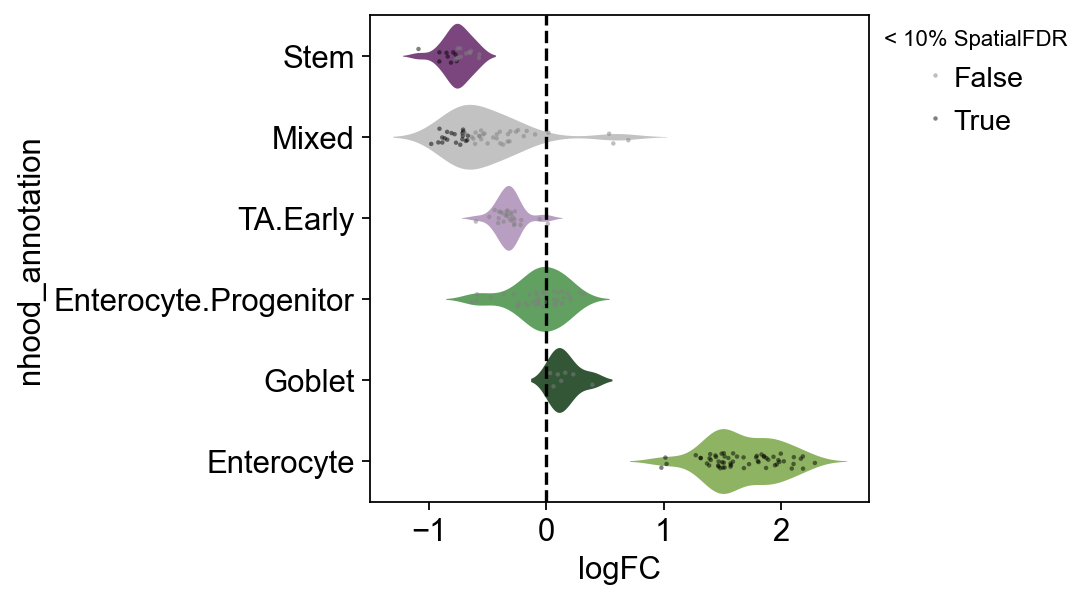

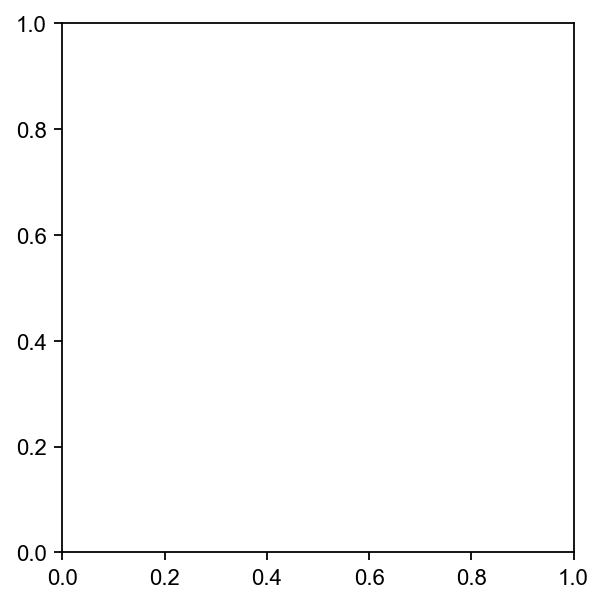

In [8]:
color_dict = dict(zip(adata.obs['cell_label'].cat.categories,
                       ov.pl.green_color[:4] + ov.pl.purple_color))
color_dict['Mixed'] = '#c2c2c2'
dct.model.plot_da_beeswarm(dct.mdata, alpha=0.1, palette=color_dict)
plt.xticks(fontsize=10); plt.yticks(fontsize=10); plt.tight_layout()

## Summary

- The `DCT(method='milopy')` wrapper runs the full Milo pipeline in
  one call, suitable for integration with the rest of the omicverse
  single-cell analysis stack.
- The object `dct.model` is an instance of the exact same Milo class
  this repo ships as `from milor_py import Milo`. See
  `tutorial_standalone.ipynb` for the direct-API version.